<a href="https://colab.research.google.com/github/joaovitor10jvpc/inferencia/blob/main/inferencia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare, chi2_contingency, chi2

# Configuração padrão do notebook (pode ajustar se necessário)
alpha = 0.05
confianca = 1 - alpha

def decisao_por_pvalor(p_valor: float, alpha: float = alpha) -> str:
    """Regra de decisão pelo p-valor (material: rejeitar H0 se p ≤ α)."""
    return "Rejeitar H0" if p_valor <= alpha else "Não rejeitar H0"

def valor_critico_chi2(gl: int, alpha: float = alpha) -> float:
    """Valor crítico do teste χ² (cauda direita)."""
    return float(chi2.ppf(1 - alpha, gl))

def imprimir_resumo_teste_chi2(chi2_obs: float, gl: int, p_valor: float, alpha: float = alpha) -> None:
    """Imprime um resumo padrão (χ², gl, p-valor, VC e decisão)."""
    vc = valor_critico_chi2(gl, alpha)
    decisao = decisao_por_pvalor(p_valor, alpha)
    print(f"χ² observado = {chi2_obs:.6f}")
    print(f"gl = {gl}")
    # p-valor muito pequeno pode aparecer como 0.0 por limites numéricos
    if p_valor == 0:
        print("p-valor < 1e-16 (muito pequeno)")
    else:
        print(f"p-valor = {p_valor:.6g}")
    print(f"Valor crítico (α={alpha:.2f}) = {vc:.6f}")
    print(f"Decisão: {decisao}")

def plot_chi2(gl: int, chi2_obs: float, alpha: float = alpha, titulo: str | None = None) -> None:
    """Plota a distribuição χ², a região crítica (cauda direita) e o valor observado.

    Observação: se χ² observado for extremamente grande, o gráfico mantém uma escala
    'útil' (até um quantil alto) e apenas anota que χ² obs está fora da escala.
    """
    vc = valor_critico_chi2(gl, alpha)
    # Mantém o gráfico legível (escala típica da distribuição)
    x_max_base = float(chi2.ppf(0.999, gl))
    x_max = max(vc, x_max_base) * 1.2
    x = np.linspace(0, x_max, 600)
    y = chi2.pdf(x, gl)

    plt.figure(figsize=(10, 6))
    plt.plot(x, y, lw=2, label=rf"Distribuição $\chi^2$ (gl={gl})")

    # Região de rejeição (cauda direita)
    x_rej = np.linspace(vc, x_max, 250)
    plt.fill_between(
        x_rej,
        chi2.pdf(x_rej, gl),
        color="red",
        alpha=0.25,
        label=rf"Região de rejeição ($\alpha$={alpha:.2f})",
    )
    plt.axvline(vc, color="red", linestyle="--", lw=2, label=f"VC = {vc:.3f}")

    # Valor observado
    if chi2_obs <= x_max:
        plt.axvline(chi2_obs, color="navy", linestyle="--", lw=2, label=f"χ² obs = {chi2_obs:.3f}")
    else:
        plt.axvline(x_max, color="navy", linestyle="--", lw=2)
        plt.annotate(
            f"χ² obs = {chi2_obs:.3f}\n(fora da escala)",
            xy=(x_max, chi2.pdf(x_max, gl)),
            xytext=(-150, 20),
            textcoords="offset points",
            arrowprops={"arrowstyle": "->", "color": "navy"},
            color="navy",
            ha="right",
        )

    plt.title(titulo or "Distribuição χ² e região crítica (cauda direita)")
    plt.xlabel(r"Estatística $\chi^2$")
    plt.ylabel("Densidade de probabilidade")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# Inferência Estatística — Testes Qui‑Quadrado (χ²)

Este notebook implementa e explica os **testes de hipóteses** baseados na distribuição $\chi^2$ (qui‑quadrado), seguindo a nomenclatura e os exemplos dos arquivos de referência do curso:
- `Testes_de_Hipotese.pdf` (passos do teste, $\alpha$, p‑valor e decisão)
- `TestesQuiquadrado.pdf` (requisitos, fórmulas e exemplos de $\chi^2$)

## Roteiro
1. Revisar rapidamente o que é um teste de hipóteses (H0/H1, $\alpha$, p‑valor e regra de decisão).
2. Revisar a ideia do teste $\chi^2$ e os requisitos para poder aplicá‑lo.
3. Aplicar aos exemplos do material (aderência, independência e homogeneidade).

---

## Fundamentos: testes de hipóteses (resumo operacional)

- **Hipótese nula (H0):** a afirmação que queremos testar (normalmente contém igualdade).
- **Hipótese alternativa (H1):** a afirmação concorrente (negação/variação de H0).
- **Nível de significância ($\alpha$):** probabilidade de **erro tipo I** (rejeitar H0 quando H0 é verdadeira).
- **p‑valor:** probabilidade (assumindo H0) de observar uma estatística **tão extrema quanto** a observada.
  - Regra (método do p‑valor): **rejeitar H0 se $p \le \alpha$**; caso contrário, **não rejeitar H0**.

Importante: **"não rejeitar H0" não significa provar que H0 é verdadeira**. Significa apenas que, com aquele $\alpha$, não houve evidência suficiente para rejeitá‑la.


---

## Testes $\chi^2$ (ideia geral)

A estatística do teste mede a discordância entre as frequências **observadas (O)** e as **esperadas (E)**:

$$
\chi^2 = \sum \frac{(O - E)^2}{E}
$$

- Testes $\chi^2$ são **unilaterais à direita**: valores grandes de $\chi^2$ indicam maior discordância (maior evidência contra H0).
- Requisito importante (para a aproximação por $\chi^2$ funcionar bem): **todas as frequências esperadas devem ser ≥ 5**.

### Tipos de teste $\chi^2$ usados aqui
1. **Aderência (goodness‑of‑fit):** **uma variável categórica** com $k$ categorias. Pergunta: as frequências observadas são compatíveis com uma **distribuição teórica** (ex.: uniforme, Benford)?
   - **H0:** as frequências observadas concordam com a distribuição alegada.
   - **H1:** não concordam (pelo menos uma categoria/probabilidade difere).
   - $E_i = n\,p_i$ (ou, no caso uniforme, $E_i = n/k$)
   - $gl = k - 1$
2. **Independência / Homogeneidade:** **tabela de contingência $r \times c$** (linhas × colunas). A conta do $\chi^2$ é a mesma; o que muda é a interpretação do desenho amostral:
   - **Independência (1 amostra):** testa se duas variáveis categóricas (linha e coluna) são **associadas** ou **independentes**.
   - **Homogeneidade (várias amostras/grupos):** testa se **populações/grupos diferentes** têm as **mesmas proporções** nas categorias.
   - Sob **H0**, calculamos $E_{ij} = \frac{(\text{total da linha i})(\text{total da coluna j})}{\text{total geral}}$
   - $gl = (r-1)(c-1)$
   - **Atenção (material):** se $p > \alpha$, não conclua “independência”; conclua apenas “não há evidência suficiente para rejeitar a independência”. Se $p \le \alpha$, conclua que há **associação** (dependência), mas **não** causalidade.

## Exemplo 1 — Teste de Aderência (últimos dígitos de pesos)

**Problema (material):** testar a alegação de que os últimos dígitos dos pesos **não** ocorrem com a mesma frequência (isto é, não seguem uma distribuição uniforme).

### Verificação dos requisitos
1. Dados obtidos de sujeitos selecionados aleatoriamente (assumido pelo enunciado do conjunto de dados).
2. Os dados são **contagens** de frequências por categoria (dígitos 0 a 9).
3. Frequências esperadas: se a distribuição fosse uniforme em 10 categorias, então $E = n/10 = 2784/10 = 278{,}4$ (≥ 5).

### Hipóteses
- **H0:** $p_0 = p_1 = \cdots = p_9$ (distribuição uniforme).
- **H1:** pelo menos uma das probabilidades difere (não uniforme).

Parâmetros: $\alpha=0{,}05$, $k=10$, $gl=k-1=9$.

n = 2784, k = 10, E = 278.4, gl = 9
χ² observado = 4490.173851
gl = 9
p-valor < 1e-16 (muito pequeno)
Valor crítico (α=0.05) = 16.918978
Decisão: Rejeitar H0


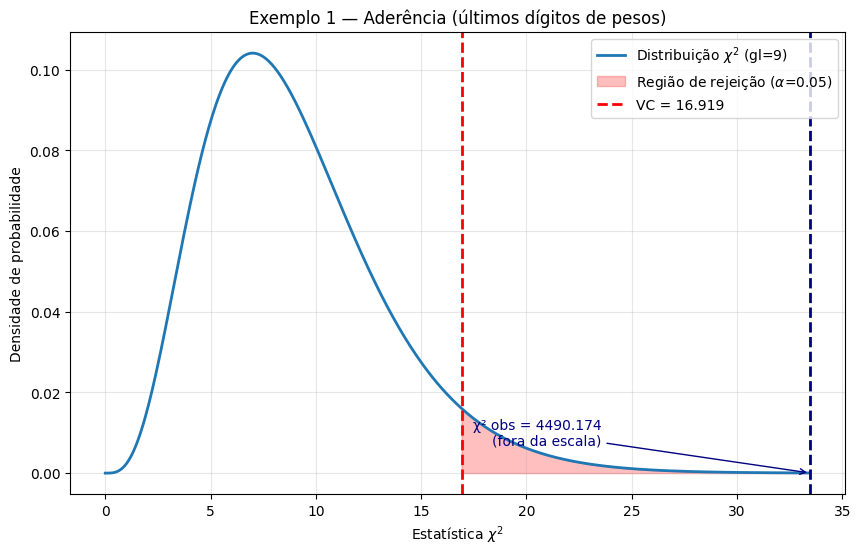

In [8]:
# Exemplo 1 — Aderência: últimos dígitos de pesos (uniforme em 10 categorias)
obs_pesos = np.array([1175, 44, 169, 111, 112, 731, 96, 110, 171, 65], dtype=float)
n = int(obs_pesos.sum())
k = obs_pesos.size
exp_pesos = np.full(k, n / k)  # 2784/10 = 278.4
gl_pesos = k - 1

chi2_pesos, p_pesos = chisquare(f_obs=obs_pesos, f_exp=exp_pesos)

print(f"n = {n}, k = {k}, E = {exp_pesos[0]:.1f}, gl = {gl_pesos}")
imprimir_resumo_teste_chi2(chi2_pesos, gl_pesos, p_pesos, alpha)

plot_chi2(gl_pesos, chi2_pesos, alpha=alpha, titulo="Exemplo 1 — Aderência (últimos dígitos de pesos)")

## Exemplo 2 — Teste de Aderência (Lei de Benford)

**Problema (material):** verificar se os dígitos líderes (1 a 9) de uma amostra de 271 observações se ajustam às proporções previstas pela Lei de Benford.

### Verificação dos requisitos
1. Amostra aleatória (assumida pelo enunciado).
2. Dados são contagens de frequências (por dígito líder).
3. Todas as frequências esperadas são ≥ 5 (a menor é $271\times 0{,}046 \approx 12{,}466$).

### Hipóteses
- **H0:** $p_1=0{,}301,\ p_2=0{,}176,\ \ldots,\ p_9=0{,}046$ (Benford).
- **H1:** pelo menos uma proporção difere (não segue Benford).

Parâmetros: $\alpha=0{,}05$, $k=9$, $gl=k-1=8$.

n = 271, k = 9, gl = 8
χ² observado = 11.279177
gl = 8
p-valor = 0.186377
Valor crítico (α=0.05) = 15.507313
Decisão: Não rejeitar H0


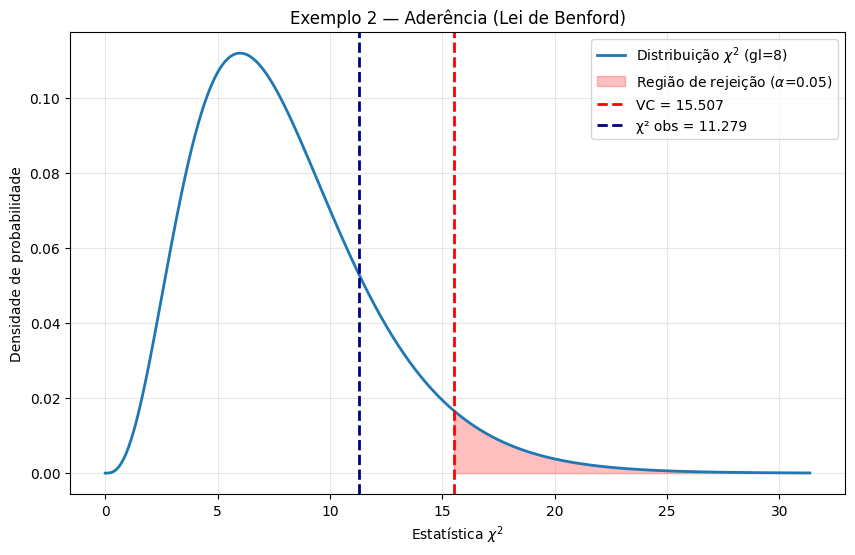

In [9]:
# Exemplo 2 — Aderência: Lei de Benford (dígitos líderes 1..9)
p_benford = np.array([0.301, 0.176, 0.125, 0.097, 0.079, 0.067, 0.058, 0.051, 0.046], dtype=float)
obs_benford = np.array([69, 40, 42, 26, 25, 16, 16, 17, 20], dtype=float)
n = int(obs_benford.sum())
k = obs_benford.size
exp_benford = n * p_benford
gl_benford = k - 1

chi2_benford, p_benford_val = chisquare(f_obs=obs_benford, f_exp=exp_benford)

print(f"n = {n}, k = {k}, gl = {gl_benford}")
imprimir_resumo_teste_chi2(chi2_benford, gl_benford, p_benford_val, alpha)

plot_chi2(gl_benford, chi2_benford, alpha=alpha, titulo="Exemplo 2 — Aderência (Lei de Benford)")

## Exemplo 3 — Teste $\chi^2$ em Tabela de Contingência (Independência)

**Problema (material):** testar a alegação de que *autismo* é independente da *vacina tríplice* (sarampo, caxumba e rubéola).

Tabela observada (O):

|                | Não vacinado | Vacinado | Total |
|---|---:|---:|---:|
| Autismo        | 25 | 64 | 89 |
| Sem autismo    | 362 | 1427 | 1789 |
| **Total**      | 387 | 1491 | 1878 |

### Verificação dos requisitos
1. Sujeitos selecionados/associados aleatoriamente aos grupos (assumido pelo estudo, como no material).
2. Dados em forma de **contagens** em tabela de dupla entrada.
3. Todas as frequências **esperadas** são ≥ 5 (a menor é 18,340 no material).

### Hipóteses
- **H0:** as variáveis (linha e coluna) são **independentes**.
- **H1:** as variáveis são **dependentes**.

Parâmetros: $\alpha=0{,}05$, $r=2$, $c=2$, $gl=(r-1)(c-1)=1$.

Atenção (material): se $p>\alpha$, **não** concluímos “independência”; concluímos apenas que **não há evidência suficiente para rejeitar a independência**.

χ² observado = 3.197518
gl = 1
p-valor = 0.0737501
Valor crítico (α=0.05) = 3.841459
Decisão: Não rejeitar H0

Frequências esperadas (E):
[[  18.34   70.66]
 [ 368.66 1420.34]]

Contribuições (O-E)^2/E:
[[2.418298 0.627687]
 [0.120307 0.031226]]


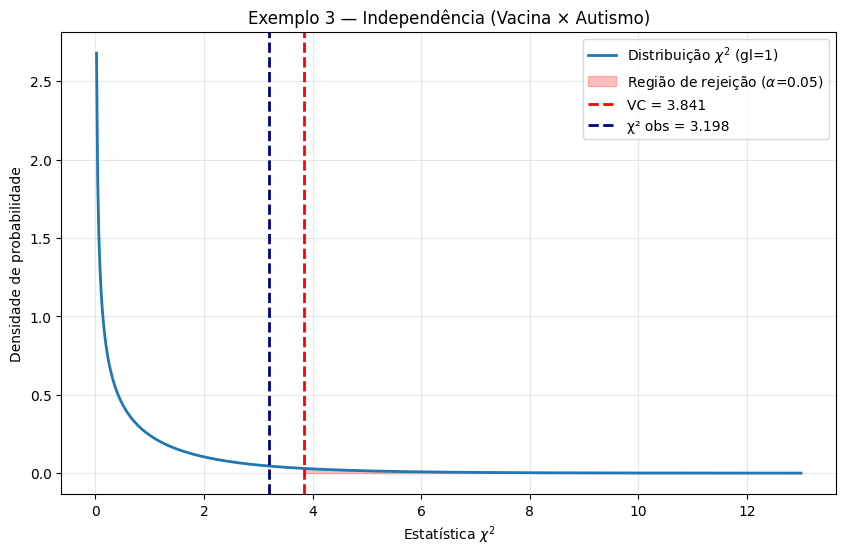

In [10]:
# Exemplo 3 — Independência: Vacina tríplice × Autismo (tabela 2×2)
obs_vacina = np.array([[25, 64], [362, 1427]], dtype=float)

# correction=False para não aplicar a correção de Yates (o material usa χ²≈3,198)
chi2_vacina, p_vacina, gl_vacina, exp_vacina = chi2_contingency(obs_vacina, correction=False)

imprimir_resumo_teste_chi2(chi2_vacina, gl_vacina, p_vacina, alpha)

print("\nFrequências esperadas (E):")
print(np.round(exp_vacina, 3))

contrib_vacina = (obs_vacina - exp_vacina) ** 2 / exp_vacina
print("\nContribuições (O-E)^2/E:")
print(np.round(contrib_vacina, 6))

plot_chi2(gl_vacina, chi2_vacina, alpha=alpha, titulo="Exemplo 3 — Independência (Vacina × Autismo)")

## Exemplo 4 — Teste $\chi^2$ de Homogeneidade (Experimento da Carteira Perdida)

**Problema (material):** um pesquisador perde 12 carteiras em cada uma de 16 cidades (A–P) e registra se a carteira foi devolvida ou não. Queremos testar se a taxa de devolução é a mesma em todas as cidades.

Tabela observada (O) — Tabela 1.8 (do print):

| Cidade | Devolvida | Não devolvida | Total |
|---|---:|---:|---:|
| A | 8 | 4 | 12 |
| B | 5 | 7 | 12 |
| C | 7 | 5 | 12 |
| D | 11 | 1 | 12 |
| E | 5 | 7 | 12 |
| F | 8 | 4 | 12 |
| G | 6 | 6 | 12 |
| H | 7 | 5 | 12 |
| I | 3 | 9 | 12 |
| J | 1 | 11 | 12 |
| K | 4 | 8 | 12 |
| L | 2 | 10 | 12 |
| M | 4 | 8 | 12 |
| N | 6 | 6 | 12 |
| O | 4 | 8 | 12 |
| P | 9 | 3 | 12 |
| **Total** | **90** | **102** | **192** |

### Verificação dos requisitos
- Dados em forma de **contagens**; amostras comparáveis (12 por cidade).
- Todas as frequências esperadas são ≥ 5:
  - $E(\text{devolvida}) = 12\times 90/192 = 5{,}625$
  - $E(\text{não devolvida}) = 12\times 102/192 = 6{,}375$

### Hipóteses
- **H0:** a devolução é independente da cidade (mesmas proporções em todas as cidades).
- **H1:** a devolução depende da cidade (pelo menos uma cidade difere).

Parâmetros: $\alpha=0{,}05$, $r=16$, $c=2$, $gl=(16-1)(2-1)=15$.

χ² observado = 35.388235
gl = 15
p-valor = 0.00216443
Valor crítico (α=0.05) = 24.995790
Decisão: Rejeitar H0

Frequências esperadas (E) — por cidade (mesmo padrão em todas):
[5.625 6.375]
Mínimo de E = 5.625

Contribuições por cidade ((O-E)^2/E):
A: devolvida=1.002777778  não devolvida=0.884803922  total=1.887581699
B: devolvida=0.069444444  não devolvida=0.061274510  total=0.130718954
C: devolvida=0.336111111  não devolvida=0.296568627  total=0.632679739
D: devolvida=5.136111111  não devolvida=4.531862745  total=9.667973856
E: devolvida=0.069444444  não devolvida=0.061274510  total=0.130718954
F: devolvida=1.002777778  não devolvida=0.884803922  total=1.887581699
G: devolvida=0.025000000  não devolvida=0.022058824  total=0.047058824
H: devolvida=0.336111111  não devolvida=0.296568627  total=0.632679739
I: devolvida=1.225000000  não devolvida=1.080882353  total=2.305882353
J: devolvida=3.802777778  não devolvida=3.355392157  total=7.158169935
K: devolvida=0.469444444  não devolvida=0.

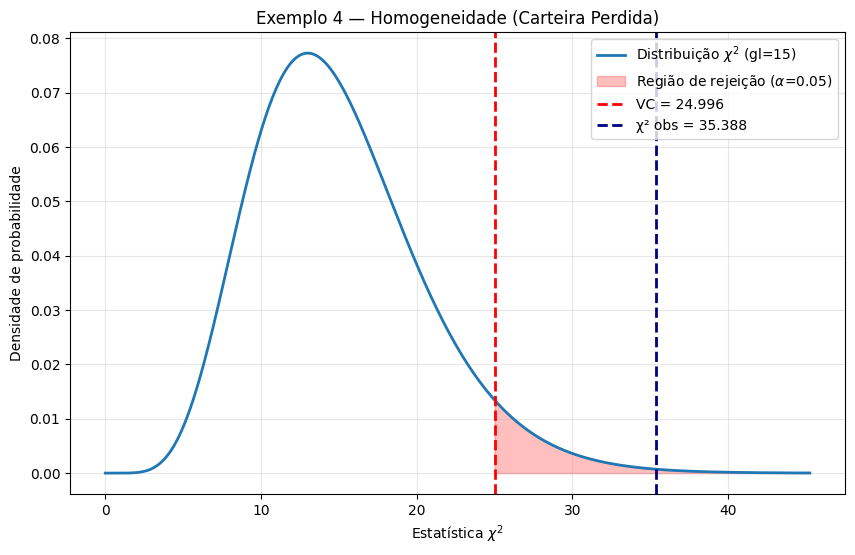

In [11]:
# Exemplo 4 — Homogeneidade: Experimento da Carteira Perdida (16×2)
obs_carteira = np.array(
    [
        [8, 4],   # A
        [5, 7],   # B
        [7, 5],   # C
        [11, 1],  # D
        [5, 7],   # E
        [8, 4],   # F
        [6, 6],   # G
        [7, 5],   # H
        [3, 9],   # I
        [1, 11],  # J
        [4, 8],   # K
        [2, 10],  # L
        [4, 8],   # M
        [6, 6],   # N
        [4, 8],   # O
        [9, 3],   # P
    ],
    dtype=float,
 )

chi2_carteira, p_carteira, gl_carteira, exp_carteira = chi2_contingency(obs_carteira, correction=False)

imprimir_resumo_teste_chi2(chi2_carteira, gl_carteira, p_carteira, alpha)

print("\nFrequências esperadas (E) — por cidade (mesmo padrão em todas):")
print(np.round(exp_carteira[0], 3))
print(f"Mínimo de E = {exp_carteira.min():.3f}")

contrib_carteira = (obs_carteira - exp_carteira) ** 2 / exp_carteira
cidades = list("ABCDEFGHIJKLMNOP")

print("\nContribuições por cidade ((O-E)^2/E):")
for cidade, (c_dev, c_nao) in zip(cidades, contrib_carteira):
    print(f"{cidade}: devolvida={c_dev:.9f}  não devolvida={c_nao:.9f}  total={(c_dev + c_nao):.9f}")

print("\nTotais (colunas e geral):")
print(f"Devolvida: {contrib_carteira[:, 0].sum():.9f}")
print(f"Não devolvida: {contrib_carteira[:, 1].sum():.9f}")
print(f"Total: {contrib_carteira.sum():.9f}")

plot_chi2(gl_carteira, chi2_carteira, alpha=alpha, titulo="Exemplo 4 — Homogeneidade (Carteira Perdida)")

## Conclusão (resumo)

- Em testes $\chi^2$, a decisão padrão é: **rejeitar H0 se $p\le \alpha$**; caso contrário, **não rejeitar H0**.
- **Exemplo 1 (pesos):** $p$ extremamente pequeno ⇒ rejeitamos H0 (não uniforme).
- **Exemplo 2 (Benford):** $p>0{,}05$ ⇒ não rejeitamos H0 (ajuste compatível com Benford).
- **Exemplo 3 (vacina × autismo):** com os dados do material e sem correção de Yates, $p>0{,}05$ ⇒ não há evidência suficiente para rejeitar independência.
- **Exemplo 4 (carteira perdida):** $p$ pequeno ⇒ rejeitamos H0 ⇒ evidência de que a devolução depende da cidade.
